<a href="https://colab.research.google.com/github/MDRobiulhassan/Machine-Learning-Course/blob/main/Forward_Propagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [29]:
df=pd.read_csv('/content/drive/MyDrive/University/7th Semester/MLL/colab/train.csv')

In [30]:
df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [31]:
df.shape

(700000, 26)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [33]:
df.isna().sum().T

,0
id,0
age,0
alcohol_consumption_per_week,0
physical_activity_minutes_per_week,0
diet_score,0
sleep_hours_per_day,0
screen_time_hours_per_day,0
bmi,0
waist_to_hip_ratio,0
systolic_bp,0


In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,700000.0,349999.500000,202072.738554,0.00,174999.75,349999.50,524999.25,699999.00
age,700000.0,50.359734,11.655520,19.00,42.00,50.00,58.00,89.00
alcohol_consumption_per_week,700000.0,2.072411,1.048189,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,700000.0,80.230803,51.195071,1.00,49.00,71.00,96.00,747.00
diet_score,700000.0,5.963695,1.463336,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,700000.0,7.002200,0.901907,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,700000.0,6.012733,2.022707,0.60,4.60,6.00,7.40,16.50
bmi,700000.0,25.874684,2.860705,15.10,23.90,25.90,27.80,38.40
waist_to_hip_ratio,700000.0,0.858766,0.037980,0.68,0.83,0.86,0.88,1.05
systolic_bp,700000.0,116.294193,11.010390,91.00,108.00,116.00,124.00,163.00


In [36]:

import pandas as pd

outlier_summary = []

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    if outlier_count > 0:
        outlier_summary.append({
            'feature': col,
            'Q1': Q1,
            'Q3': Q3,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': outlier_count
        })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,age,42.00,58.00,18.000,82.000,1013
1,alcohol_consumption_per_week,1.00,3.00,-2.000,6.000,509
2,physical_activity_minutes_per_week,49.00,96.00,-21.500,166.500,33490
3,diet_score,5.00,7.00,2.000,10.000,1997
4,sleep_hours_per_day,6.40,7.60,4.600,9.400,6152
5,screen_time_hours_per_day,4.60,7.40,0.400,11.600,2337
6,bmi,23.90,27.80,18.050,33.650,4254
7,waist_to_hip_ratio,0.83,0.88,0.755,0.955,6159
8,systolic_bp,108.00,124.00,84.000,148.000,775
9,diastolic_bp,71.00,80.00,57.500,93.500,5752


In [37]:
cols_to_drop = ['id', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']

df = df.drop(columns=cols_to_drop)

print(df.columns)

Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'diagnosed_diabetes'],
      dtype='object')


In [38]:
import pandas as pd

outlier_summary = []

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()

    if outlier_count > 0:
        outlier_summary.append({
            'feature': col,
            'Q1': Q1,
            'Q3': Q3,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': outlier_count
        })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,age,42.00,58.00,18.000,82.000,1013
1,alcohol_consumption_per_week,1.00,3.00,-2.000,6.000,509
2,physical_activity_minutes_per_week,49.00,96.00,-21.500,166.500,33490
3,diet_score,5.00,7.00,2.000,10.000,1997
4,sleep_hours_per_day,6.40,7.60,4.600,9.400,6152
5,screen_time_hours_per_day,4.60,7.40,0.400,11.600,2337
6,bmi,23.90,27.80,18.050,33.650,4254
7,waist_to_hip_ratio,0.83,0.88,0.755,0.955,6159
8,systolic_bp,108.00,124.00,84.000,148.000,775
9,diastolic_bp,71.00,80.00,57.500,93.500,5752


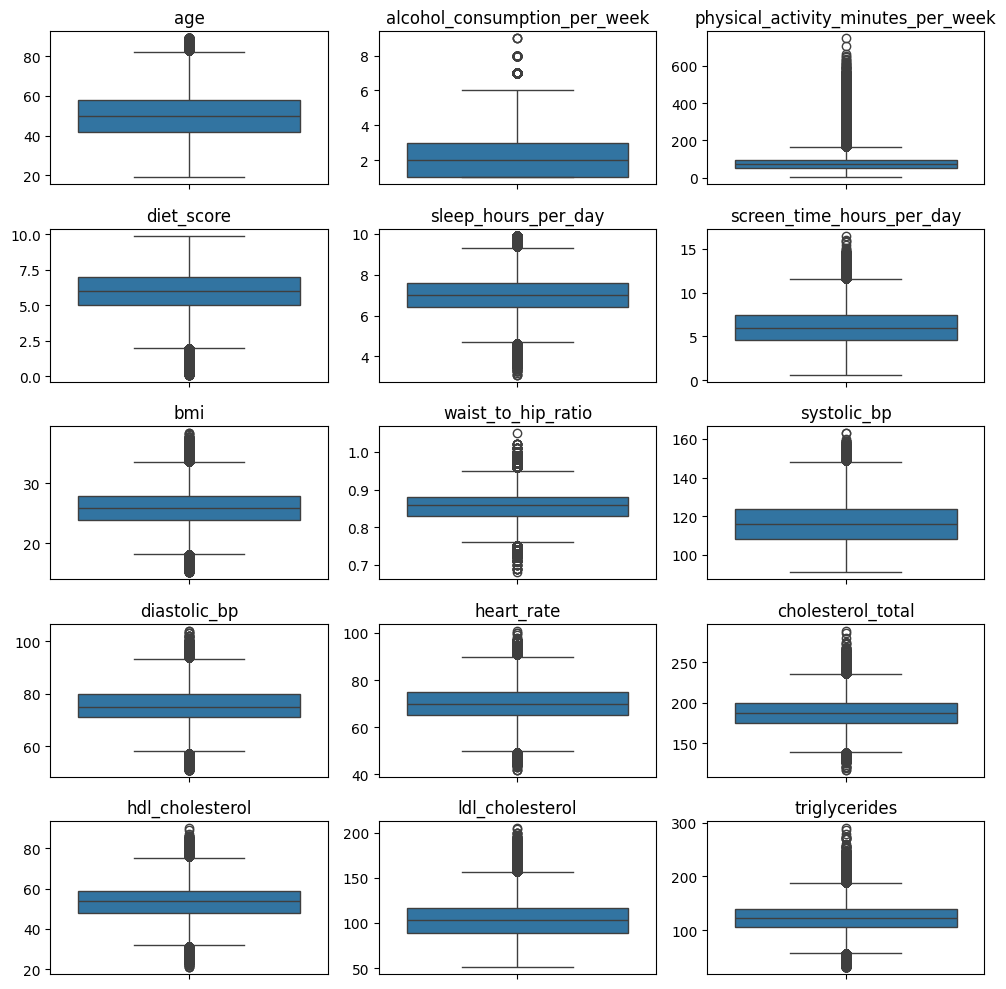

In [39]:
numeric_features = [
    'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week',
    'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
    'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
    'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides'
]

rows = 5
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(10, 10))

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(y=df[feature], ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [40]:

numeric_features = [
    'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week',
    'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
    'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
    'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides'
]

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[feature] = df[feature].clip(lower, upper)

print("Outliers have been capped.")

Outliers have been capped.


In [41]:
capped_summary = []

for feature in numeric_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    capped_summary.append([feature, Q1, Q3, lower, upper, 0])

capped_df = pd.DataFrame(capped_summary, columns=['feature','Q1','Q3','lower_bound','upper_bound','outlier_count'])

capped_df

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,age,42.00,58.00,18.000,82.000,0
1,alcohol_consumption_per_week,1.00,3.00,-2.000,6.000,0
2,physical_activity_minutes_per_week,49.00,96.00,-21.500,166.500,0
3,diet_score,5.00,7.00,2.000,10.000,0
4,sleep_hours_per_day,6.40,7.60,4.600,9.400,0
5,screen_time_hours_per_day,4.60,7.40,0.400,11.600,0
6,bmi,23.90,27.80,18.050,33.650,0
7,waist_to_hip_ratio,0.83,0.88,0.755,0.955,0
8,systolic_bp,108.00,124.00,84.000,148.000,0
9,diastolic_bp,71.00,80.00,57.500,93.500,0


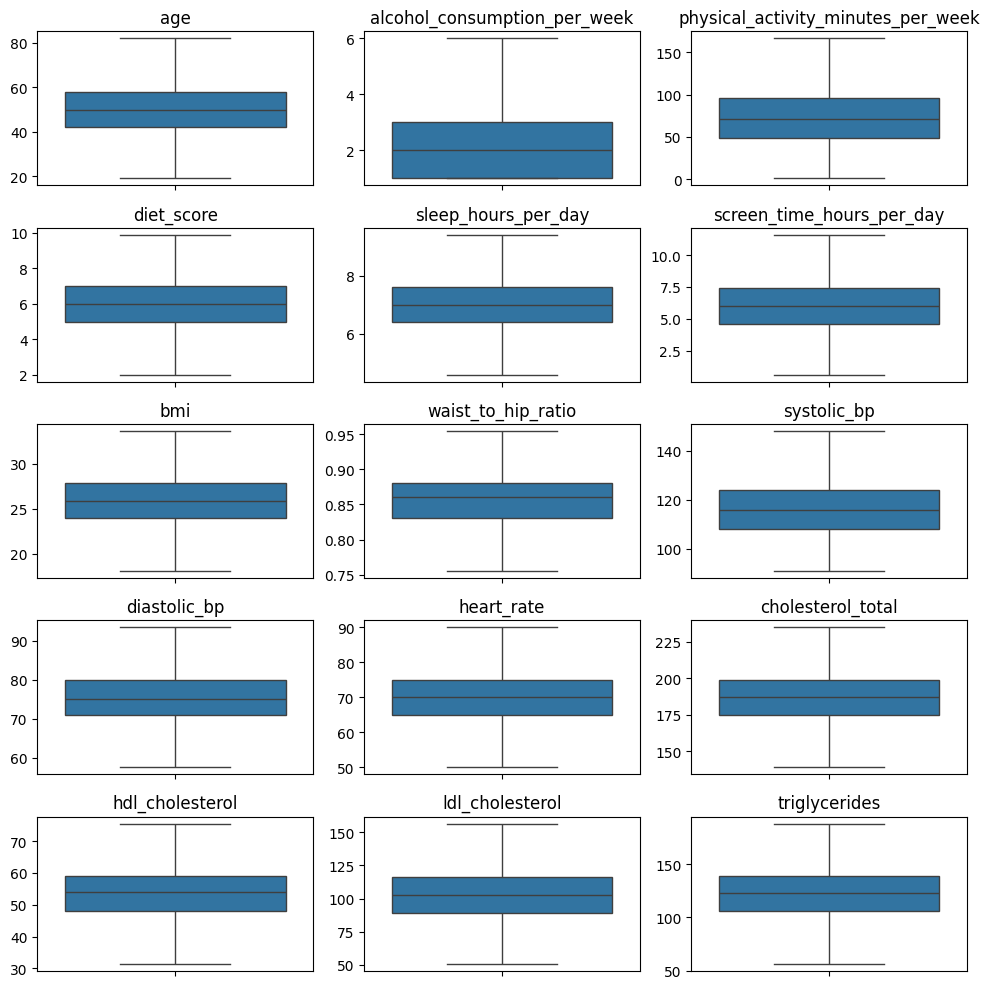

In [42]:
numeric_features = [
    'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week',
    'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
    'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
    'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides'
]

rows = 5
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(10, 10))

axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(y=df[feature], ax=axes[i])
    axes[i].set_title(feature)
    axes[i].set_ylabel('')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [43]:
# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

print(df.shape)

(700000, 34)


In [44]:
X = df.drop("diagnosed_diabetes", axis=1).values
y = df["diagnosed_diabetes"].values.reshape(-1, 1)

print(X.shape)
print(y.shape)

(700000, 33)
(700000, 1)


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)

(560000, 33)


In [46]:
import numpy as np
import matplotlib.pyplot as plt

# For reproducibility
np.random.seed(42)

In [47]:
def relu(Z):
   """ReLU activation function: max(0, Z)"""
   return np.maximum(0, Z)

def sigmoid(Z):
   """Sigmoid activation function: 1/(1 + e^(-Z))"""
   return 1 / (1 + np.exp(-Z))

def softmax(Z):
   """Softmax activation function for multi-class classification"""
   # Subtract max for numerical stability (prevents overflow)
   exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
   return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [48]:
class NeuralNetwork:
   def __init__(self, layer_dims, activations):
       """
       Initialize a neural network with specified layer dimensions and activations

       Parameters:
       - layer_dims: List of integers representing the number of neurons in each layer
                    (including input and output layers)
       - activations: List of activation functions for each layer (excluding input layer)
       """
       self.L = len(layer_dims) - 1  # Number of layers (excluding input layer)
       self.layer_dims = layer_dims
       self.activations = activations
       self.parameters = {}

       # Initialize parameters (weights and biases)
       self.initialize_parameters()

   def initialize_parameters(self):
       """Initialize weights and biases with small random values"""
       for l in range(1, self.L + 1):
           # He initialization for weights - helps with training deep networks
           self.parameters[f'W{l}'] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) * np.sqrt(2 / self.layer_dims[l-1])
           self.parameters[f'b{l}'] = np.zeros((self.layer_dims[l], 1))

   def forward_propagation(self, X):
       """
       Perform forward propagation through the network

       Parameters:
       - X: Input data (n_features, batch_size)

       Returns:
       - AL: Output of the network
       - caches: Dictionary containing all activations and pre-activations
       """
       caches = {}
       A = X  # Input layer activation
       caches['A0'] = X

       # Process through L-1 layers (excluding output layer)
       for l in range(1, self.L):
           A_prev = A

           # Get weights and biases for current layer
           W = self.parameters[f'W{l}']
           b = self.parameters[f'b{l}']

           # Forward propagation for current layer
           Z = np.dot(W, A_prev) + b

           # Apply activation function
           activation_function = self.activations[l-1]
           if activation_function == "relu":
               A = relu(Z)
           elif activation_function == "sigmoid":
               A = sigmoid(Z)

           # Store values for backpropagation
           caches[f'Z{l}'] = Z
           caches[f'A{l}'] = A

       # Output layer
       W = self.parameters[f'W{self.L}']
       b = self.parameters[f'b{self.L}']
       Z = np.dot(W, A) + b

       # Apply output activation function
       activation_function = self.activations[self.L-1]
       if activation_function == "sigmoid":
           AL = sigmoid(Z)
       elif activation_function == "softmax":
           AL = softmax(Z)
       elif activation_function == "linear":
           AL = Z  # No activation for regression

       # Store output layer values
       caches[f'Z{self.L}'] = Z
       caches[f'A{self.L}'] = AL

       return AL, caches